# Vanilla DQN for LunarLander

A straightforward implementation of Deep Q-Network without any fancy improvements or extensions. This notebook trains a DQN agent to solve the LunarLander environment.

## 1. Setup and Imports

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from gymnasium import make

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Q-Network Architecture

In [10]:
class QNetwork(nn.Module):
    """Simple neural network for Q-value approximation"""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

## 3. Experience Replay Buffer

In [11]:
class ReplayBuffer:
    """Experience replay buffer for storing transitions"""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)

        states, actions, rewards, next_states, dones = zip(*[self.buffer[i] for i in indices])

        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array(actions), dtype=torch.long, device=device)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
        dones = torch.tensor(np.array(dones), dtype=torch.float32, device=device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

## 4. DQN Agent

In [12]:
class VanillaDQN:
    """Vanilla DQN Agent"""
    def __init__(self, state_dim, action_dim, learning_rate=1e-3, gamma=0.99, epsilon=1.0,
                 epsilon_decay=0.995, epsilon_min=0.01, hidden_dim=128, buffer_capacity=10000):

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Networks
        self.q_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        # Optimizer
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)

        # Replay buffer
        self.replay_buffer = ReplayBuffer(capacity=buffer_capacity)

    def select_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        """Store transition in replay buffer"""
        self.replay_buffer.add(state, action, reward, next_state, done)

    def update(self, batch_size):
        """Update Q-network using experience replay"""
        if len(self.replay_buffer) < batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        # Compute Q-values for chosen actions
        q_values = self.q_network(states)
        q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        # Compute target Q-values
        with torch.no_grad():
            next_q_values = self.target_network(next_states)
            max_next_q_values = next_q_values.max(dim=1)[0]
            target_q_values = rewards + self.gamma * max_next_q_values * (1 - dones)

        # Compute loss
        loss = nn.MSELoss()(q_values, target_q_values)

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Update target network weights"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## 5. Training Function

In [13]:
def train_dqn(num_episodes=500, batch_size=32, update_frequency=4, target_update_frequency=100):
    """Train the DQN agent on LunarLander"""

    # Create environment
    env = make('LunarLander-v3')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    print(f"State dimension: {state_dim}")
    print(f"Action dimension: {action_dim}")

    # Create agent
    agent = VanillaDQN(state_dim, action_dim)

    # Training loop
    episode_rewards = []
    episode_losses = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_loss = []
        done = False
        step = 0

        while not done:
            # Select and execute action
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store transition
            agent.store_transition(state, action, reward, next_state, done)

            # Update network
            if step % update_frequency == 0:
                loss = agent.update(batch_size)
                if loss is not None:
                    episode_loss.append(loss)

            episode_reward += reward
            state = next_state
            step += 1

        # Update target network
        if (episode + 1) % target_update_frequency == 0:
            agent.update_target_network()

        # Decay epsilon
        agent.decay_epsilon()

        # Record metrics
        episode_rewards.append(episode_reward)
        if episode_loss:
            episode_losses.append(np.mean(episode_loss))

        # Print progress
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode + 1}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent.epsilon:.3f}")

    env.close()

    return agent, episode_rewards, episode_losses

## 6. Evaluation Function

In [19]:
def evaluate_dqn(agent, num_episodes=10, render=False):
    """Evaluate the trained DQN agent"""
    env = make('LunarLander-v3', render_mode='human' if render else None)

    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.select_action(state, training=False)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

        episode_rewards.append(episode_reward)
        print(f"Evaluation Episode {episode + 1}: Reward = {episode_reward:.2f}")

    env.close()

    avg_reward = np.mean(episode_rewards)
    print(f"\nAverage evaluation reward: {avg_reward:.2f}")

    return episode_rewards

## 7. Visualization Function

In [20]:
def plot_results(episode_rewards, episode_losses):
    """Plot training results"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot episode rewards
    axes[0].plot(episode_rewards, alpha=0.6, label='Episode Reward')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title('Training: Episode Rewards')
    axes[0].grid(True, alpha=0.3)

    # Plot smoothed rewards
    window = 50
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(episode_rewards)), smoothed_rewards, color='red',
                 label=f'Smoothed (window={window})', linewidth=2)
    axes[0].legend()

    # Plot loss
    if episode_losses:
        axes[1].plot(episode_losses, alpha=0.6)
        axes[1].set_xlabel('Update Step')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Training: Loss')
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. Train the Agent

This cell trains the DQN agent for 500 episodes. This may take a few minutes.

In [21]:
print("="*50)
print("Training Vanilla DQN on LunarLander")
print("="*50)

agent, episode_rewards, episode_losses = train_dqn(
    num_episodes=500,
    batch_size=32,
    update_frequency=4,
    target_update_frequency=100
)

Training Vanilla DQN on LunarLander
State dimension: 8
Action dimension: 4
Episode 50/500 | Avg Reward (last 50): -170.87 | Epsilon: 0.778
Episode 100/500 | Avg Reward (last 50): -115.05 | Epsilon: 0.606
Episode 150/500 | Avg Reward (last 50): -112.01 | Epsilon: 0.471
Episode 200/500 | Avg Reward (last 50): -129.54 | Epsilon: 0.367
Episode 250/500 | Avg Reward (last 50): -95.11 | Epsilon: 0.286
Episode 300/500 | Avg Reward (last 50): -40.40 | Epsilon: 0.222
Episode 350/500 | Avg Reward (last 50): -88.31 | Epsilon: 0.173
Episode 400/500 | Avg Reward (last 50): -58.19 | Epsilon: 0.135
Episode 450/500 | Avg Reward (last 50): -64.49 | Epsilon: 0.105
Episode 500/500 | Avg Reward (last 50): -27.07 | Epsilon: 0.082


## 9. Evaluate the Trained Agent

In [22]:
print("\n" + "="*50)
print("Evaluating Trained Agent")
print("="*50)

eval_rewards = evaluate_dqn(agent, num_episodes=10, render=False)


Evaluating Trained Agent
Evaluation Episode 1: Reward = -27.09
Evaluation Episode 2: Reward = -150.14
Evaluation Episode 3: Reward = -46.51
Evaluation Episode 4: Reward = -118.21
Evaluation Episode 5: Reward = 3.11
Evaluation Episode 6: Reward = -125.68
Evaluation Episode 7: Reward = 14.22
Evaluation Episode 8: Reward = -24.27
Evaluation Episode 9: Reward = -14.76
Evaluation Episode 10: Reward = -20.27

Average evaluation reward: -50.96


## 10. Visualize Results

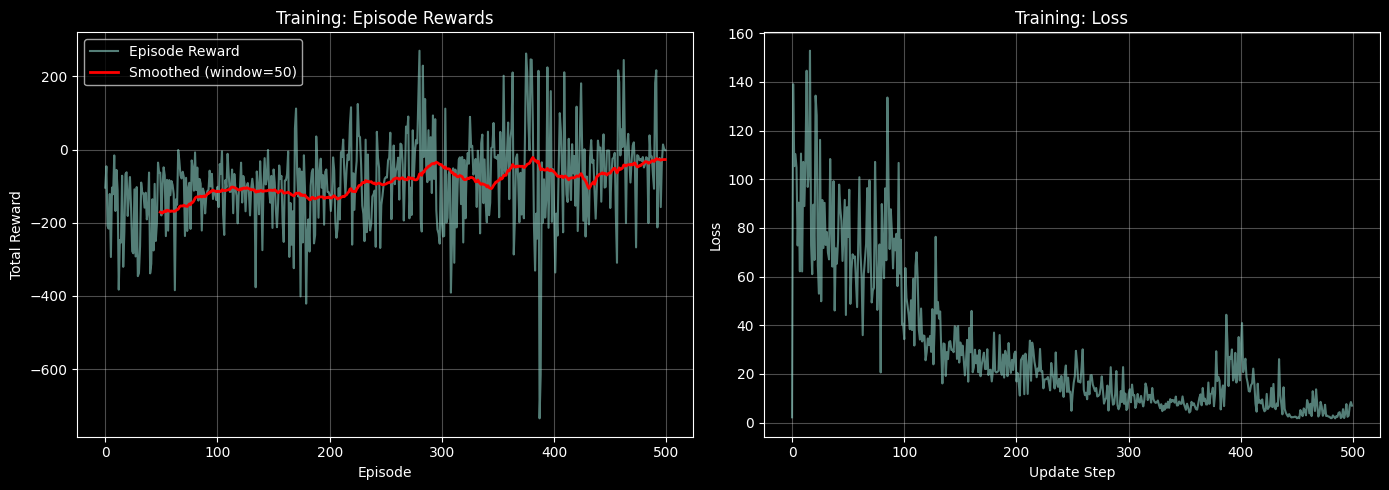

In [23]:
plot_results(episode_rewards, episode_losses)

## Summary

This notebook implements a vanilla DQN agent that learns to solve the LunarLander environment. The key components are:

- **Q-Network**: A simple 2-layer neural network that approximates Q-values
- **Target Network**: A separate network updated periodically to stabilize training
- **Experience Replay**: Stores and samples transitions to break temporal correlations
- **Epsilon-Greedy Exploration**: Balances exploration (random actions) and exploitation (best actions)
- **DQN Update Rule**: Uses Bellman equation to update Q-values

The agent should achieve positive rewards within the 500 training episodes.